# Random Forest

Santiago Verdugo | CS 549 Final Project (Spring 2026)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    fbeta_score
)

warnings.filterwarnings("ignore")

In [2]:
X_train = pd.read_csv("data/X_train.csv")
y_train = pd.read_csv("data/y_train.csv").squeeze()

X_test = pd.read_csv("data/X_test.csv")
y_test = pd.read_csv("data/y_test.csv").squeeze()

In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

model = CalibratedClassifierCV(rf, method="isotonic", cv=3)
model.fit(X_train, y_train)

test_probs = model.predict_proba(X_test)[:, 1]

In [4]:
best_f1 = -1
best_t = None

thresholds = [0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.25, 0.3]

for t in thresholds:
    y_test_pred = (test_probs >= t).astype(int)

    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    f2 = fbeta_score(y_test, y_test_pred, beta=2, zero_division=0)

    print(f"\nTest Threshold: {t}")
    print("Recall:", recall_score(y_test, y_test_pred, zero_division=0))
    print("Precision:", precision_score(y_test, y_test_pred, zero_division=0))
    print("F1:", f1)
    print("F2:", f2)
    print(confusion_matrix(y_test, y_test_pred))

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest threshold: {best_t}")
print(f"Best F1: {best_f1}")


Test Threshold: 0.05
Recall: 0.36016260162601627
Precision: 0.14117272147864882
F1: 0.20283882783882784
F2: 0.2748821047406304
[[9987 2695]
 [ 787  443]]

Test Threshold: 0.075
Recall: 0.3130081300813008
Precision: 0.14951456310679612
F1: 0.202365308804205
F2: 0.256837891927952
[[10492  2190]
 [  845   385]]

Test Threshold: 0.1
Recall: 0.21951219512195122
Precision: 0.16433353621424224
F1: 0.18795683954054995
F2: 0.20569861343897608
[[11309  1373]
 [  960   270]]

Test Threshold: 0.125
Recall: 0.20243902439024392
Precision: 0.1689280868385346
F1: 0.1841715976331361
F2: 0.19471379418204568
[[11457  1225]
 [  981   249]]

Test Threshold: 0.15
Recall: 0.16178861788617885
Precision: 0.181073703366697
F1: 0.17088879347359381
F2: 0.16530985213490612
[[11782   900]
 [ 1031   199]]

Test Threshold: 0.2
Recall: 0.11544715447154472
Precision: 0.20170454545454544
F1: 0.1468459152016546
F2: 0.12624466571834994
[[12120   562]
 [ 1088   142]]

Test Threshold: 0.25
Recall: 0.08373983739837398
Preci

In [5]:
y_test_pred = (test_probs >= best_t).astype(int)

print(f"\nFinal Test Results using threshold: {best_t}")
print("Recall:", recall_score(y_test, y_test_pred, zero_division=0))
print("Precision:", precision_score(y_test, y_test_pred, zero_division=0))
print("F1:", f1_score(y_test, y_test_pred, zero_division=0))
print("F2:", fbeta_score(y_test, y_test_pred, beta=2, zero_division=0))
print(confusion_matrix(y_test, y_test_pred))


Final Test Results using threshold: 0.05
Recall: 0.36016260162601627
Precision: 0.14117272147864882
F1: 0.20283882783882784
F2: 0.2748821047406304
[[9987 2695]
 [ 787  443]]



Test probability summary:
count    13912.000000
mean         0.044303
std          0.096475
min          0.000000
25%          0.002175
50%          0.008948
75%          0.044377
max          0.999613
dtype: float64


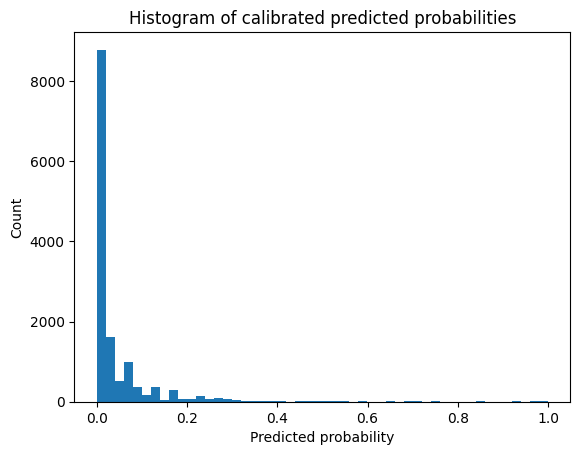

In [6]:
print("\nTest probability summary:")
print(pd.Series(test_probs).describe())

plt.hist(test_probs, bins=50)
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Histogram of calibrated predicted probabilities")
plt.show()